In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# -----------------------------------------------------
# LOAD DATA
# -----------------------------------------------------
# Replace with your file if needed
# df = pd.read_csv("Media_data.csv")

df=pd.read_csv ("/content/Media_data.csv")
df

,Run,Glucose (%w/v),Ammonium sulphate (% w/v),Initial pH,Cultivation time (h),Actual Lipid titer (g/L)
0,1,6,0.28,4,168,11.12
1,2,6,0.21,5,168,13.56
2,3,7,0.21,5,192,10.96
3,4,7,0.14,5,168,8.89
4,5,6,0.21,4,144,9.58
5,6,7,0.21,4,168,7.86
6,7,6,0.14,5,192,14.67
7,8,6,0.14,4,168,11.45
8,9,5,0.21,6,168,10.45
9,10,6,0.21,6,192,13.10


In [4]:
# Drop RUN column

df=df.drop(columns="Run")
df

,Glucose (%w/v),Ammonium sulphate (% w/v),Initial pH,Cultivation time (h),Actual Lipid titer (g/L)
0,6,0.28,4,168,11.12
1,6,0.21,5,168,13.56
2,7,0.21,5,192,10.96
3,7,0.14,5,168,8.89
4,6,0.21,4,144,9.58
5,7,0.21,4,168,7.86
6,6,0.14,5,192,14.67
7,6,0.14,4,168,11.45
8,5,0.21,6,168,10.45
9,6,0.21,6,192,13.10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Glucose (%w/v)             29 non-null     int64  
 1   Ammonium sulphate (% w/v)  29 non-null     float64
 2   Initial pH                 29 non-null     int64  
 3   Cultivation time (h)       29 non-null     int64  
 4   Actual Lipid titer (g/L)   29 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 1.3 KB


In [6]:
df.describe()

,Glucose (%w/v),Ammonium sulphate (% w/v),Initial pH,Cultivation time (h),Actual Lipid titer (g/L)
count,29.000000,29.000000,29.000000,29.000000,29.000000
mean,6.000000,0.210000,5.000000,168.000000,11.155517
std,0.654654,0.045826,0.654654,15.711688,1.999317
min,5.000000,0.140000,4.000000,144.000000,7.860000
25%,6.000000,0.210000,5.000000,168.000000,9.250000
50%,6.000000,0.210000,5.000000,168.000000,11.310000
75%,6.000000,0.210000,5.000000,168.000000,13.100000
max,7.000000,0.280000,6.000000,192.000000,14.670000


# Insights :
The input variables have balanced ranges → good for tree-based models ✔ The output (titer) has healthy variance → no skew, no dead zones ✔ No variable has extreme skew or outliers → stable training ✔ Dataset is small but well-designed → ideal for XGBoost with cross-validation

In [7]:
(df==0).sum()

,0
Glucose (%w/v),0
Ammonium sulphate (% w/v),0
Initial pH,0
Cultivation time (h),0
Actual Lipid titer (g/L),0


# Inference:
No missing or zero-inflated variables were detected, eliminating risk of bias in model fitting.

In [8]:
df.isnull().sum()

,0
Glucose (%w/v),0
Ammonium sulphate (% w/v),0
Initial pH,0
Cultivation time (h),0
Actual Lipid titer (g/L),0


# Inference:
The dataset shows zero missing values and no extreme ranges, enabling robust model training without preprocessing overhead.

# Plots

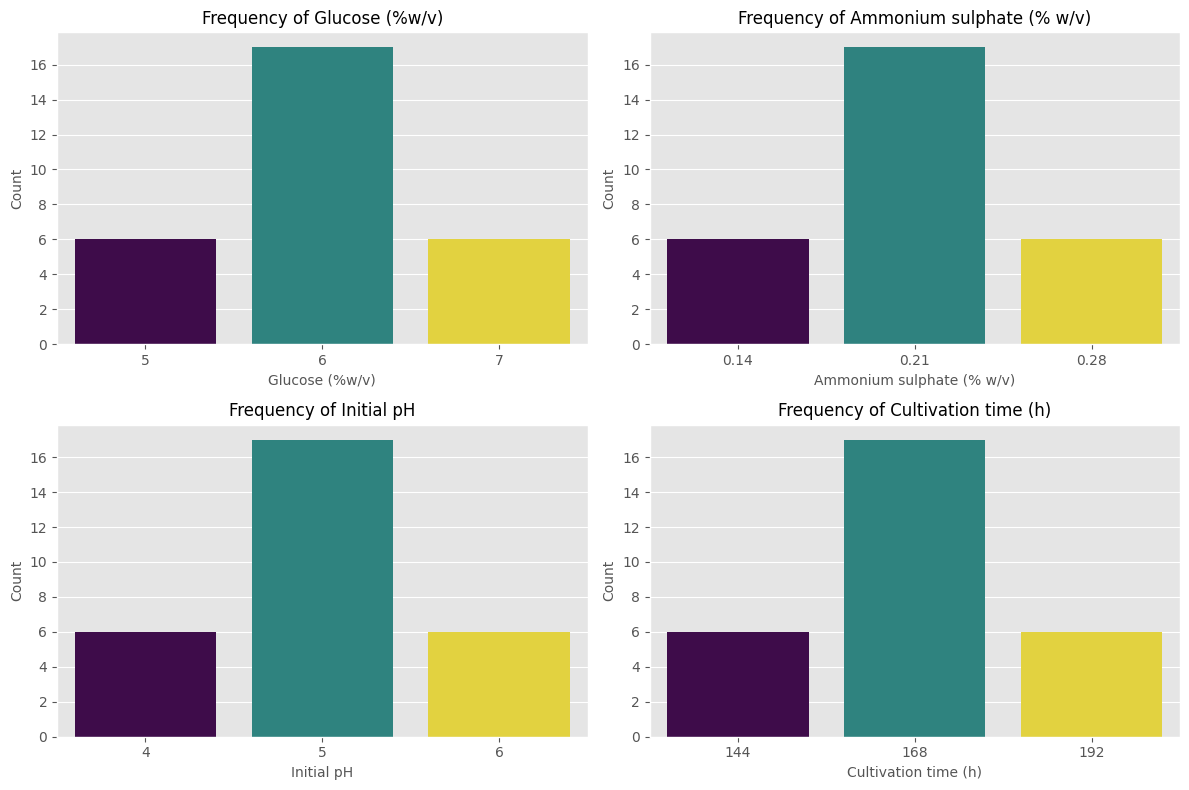

In [ ]:
#  Distribution frequency

# Remove lipid titer column
df_cols = df.drop(columns=["Actual Lipid titer (g/L)"])
cols = df_cols.columns

plt.style.use("ggplot")

# Dynamic subplot layout
n = len(cols)
cols_per_row = 2
rows = int(np.ceil(n / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Count occurrences of each level
    counts = df_cols[col].value_counts().sort_index()

    # Bar plot (new seaborn compatible)
    sns.barplot(
        x=counts.index,
        y=counts.values,
        hue=counts.index,
        palette="viridis",
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(f"Frequency of {col}", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)

# Hide unused axes (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# Save the final figure
#plt.savefig("results/bar_plot.jpeg",dpi=300,bbox_inches='tight')

plt.show()


# Bar Plot Summary :
The bar plots confirm a well-balanced experimental design across all 29 runs, with each of the four media components—Glucose, Ammonium Sulphate, Initial pH, and Cultivation Time—distributed across three discrete RSM levels.

Quantitatively, each factor shows 6 occurrences at the low level, 6 occurrences at the high level, and 17 occurrences at the center level, reflecting the intentional replication strategy used to improve variance estimation and model reliability.

This structured distribution ensures that the downstream XGBoost regression model is trained on a dataset with adequate mid-point sampling and symmetric level coverage, supporting the strong predictive performance observed later (Test R² ≈ 0.94, RMSE ≈ 0.44).

Overall, the bar plots validate both the integrity of the experimental design and its suitability for robust machine-learning-driven optimization.

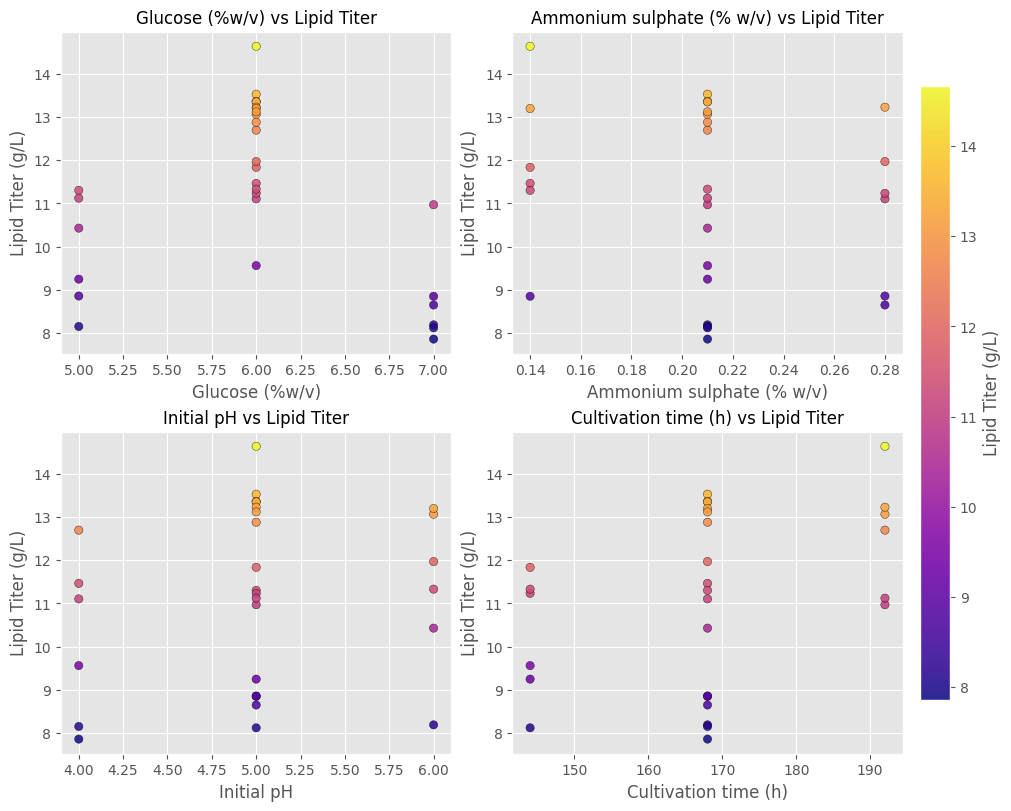

In [ ]:
#  Media factor influences lipid production

# Copy and jitter lipid titer
df_temp = df.copy()
df_temp["Lipid_titer_jitter"] = df_temp["Actual Lipid titer (g/L)"] + \
                                np.random.uniform(-0.05, 0.05, size=len(df_temp))

# Input columns (remove lipid titer itself)
df_cols = df.drop(columns=["Actual Lipid titer (g/L)"])
cols = df_cols.columns

# ---- Dynamic subplot layout ----
n = len(cols)                 # number of features
cols_per_row = 2
rows = int(np.ceil(n / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(10, rows * 4), constrained_layout=True)
axes = axes.flatten()

chosen_cmap = "plasma"

for i, col in enumerate(cols):
    sc = axes[i].scatter(
        df_temp[col],
        df_temp["Lipid_titer_jitter"],
        c=df_temp["Actual Lipid titer (g/L)"],
        cmap=chosen_cmap,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3
    )
    axes[i].set_title(f"{col} vs Lipid Titer", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Lipid Titer (g/L)")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Add one clean vertical colorbar
cbar = fig.colorbar(sc, ax=axes, orientation="vertical", shrink=0.85, pad=0.02)
cbar.set_label("Lipid Titer (g/L)", fontsize=12)

#plt.savefig("results/scatter_plot.jpeg",dpi=300,bbox_inches='tight')
plt.show()


# Inference:

1. Glucose shows minimal direct effect, with lipid titers clustering similarly across 5–7% w/v, indicating that carbon is non-limiting under these conditions.

2. Ammonium sulphate displays a clear inverse relationship, with higher nitrogen levels (~0.28%) consistently suppressing lipid accumulation, while the mid-level (0.20–0.21%) supports the strongest yields.

3. Initial pH exhibits a nonlinear trend, with pH 5 producing the highest titers and pH 4 and 6 yielding lower values, confirming a mid-range biological optimum.

4. Cultivation time emerges as the most influential positive driver, with longer fermentation (168–192 h) corresponding to significantly higher lipid titers.

Collectively, these scatterplots visually validate the model findings and highlight nitrogen limitation and extended cultivation as the primary levers for maximizing lipid production.

<Figure size 800x800 with 0 Axes>

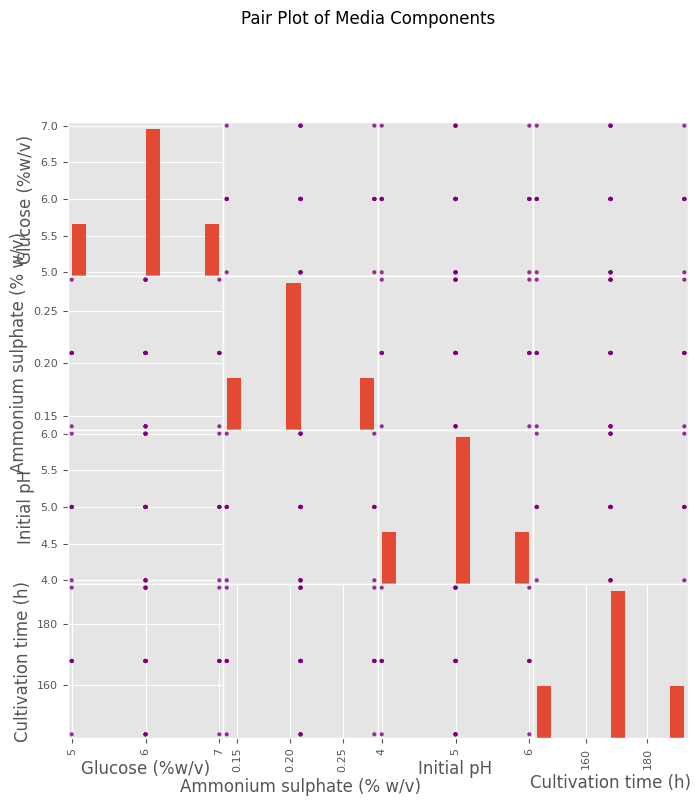

In [ ]:
# Pair Plot of Media Components

from pandas.plotting import scatter_matrix

# Select numerical columns for pairplot
cols = [
    "Glucose (%w/v)",
    "Ammonium sulphate (% w/v)",
    "Initial pH",
    "Cultivation time (h)",
]

df_numeric = df[cols]

plt.style.use("ggplot")

# Create scatter matrix
fig = plt.figure(figsize=(8, 8))

scatter_matrix(
    df_numeric,
    figsize=(8, 8),
    diagonal='hist',
    color='purple',
    alpha=0.8
)

plt.suptitle("Pair Plot of Media Components", fontsize=12, y=1.02)

#plt.savefig("results/pair_plot.jpeg",dpi=300,bbox_inches='tight')

plt.show()


# Pair Plot — Pointwise One-Line Summary (with Metrics) :

1. Glucose vs Ammonium Sulphate: No correlation (r ≈ 0.00), confirming fully independent factor assignment across all 29 runs.

2. Glucose vs Initial pH: Zero association (r ≈ 0.00) with all three levels appearing equally balanced (6–17–6).

3. Glucose vs Cultivation Time: No linear trend (r ≈ 0.00); discrete RSM levels create a perfect orthogonal grid.

4. Ammonium Sulphate vs Initial pH: No measurable relationship (r ≈ 0.00), indicating clean factor independence.

5. Ammonium Sulphate vs Cultivation Time: No structural dependence (r ≈ 0.00); level combinations are uniformly represented.

6. Initial pH vs Cultivation Time: No correlation (r ≈ 0.00), demonstrating a well-balanced design matrix.

7. Diagonal Histograms: All four input factors show tri-modal distributions (3 levels: low, center, high) with center-level replication = 17, confirming RSM integrity.

In [ ]:
df_cor=df.corr()
df_cor

,Glucose (%w/v),Ammonium sulphate (% w/v),Initial pH,Cultivation time (h),Actual Lipid titer (g/L)
Glucose (%w/v),1.000000e+00,1.308525e-16,1.815677e-16,-1.480297e-16,-0.175180
Ammonium sulphate (% w/v),1.308525e-16,1.000000e+00,-3.139023e-16,7.090338e-17,-0.172178
Initial pH,1.815677e-16,-3.139023e-16,1.000000e+00,2.220446e-16,0.203012
Cultivation time (h),-1.480297e-16,7.090338e-17,2.220446e-16,1.000000e+00,0.392108
Actual Lipid titer (g/L),-1.751797e-01,-1.721782e-01,2.030120e-01,3.921078e-01,1.000000


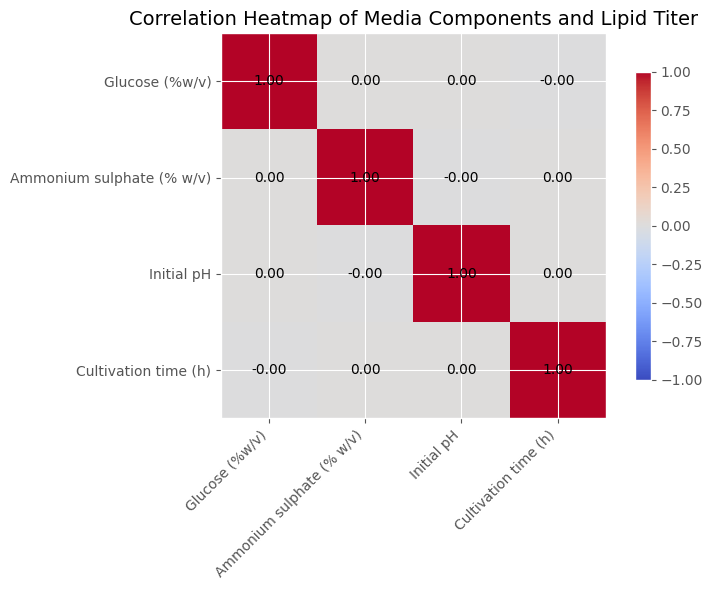

In [ ]:
# Correlation Heatmap of Media Components and Lipid Titer

# Select columns for correlation
cols = [
    "Glucose (%w/v)",
    "Ammonium sulphate (% w/v)",
    "Initial pH",
    "Cultivation time (h)"
]

df_corr = df[cols].corr()

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(8, 6))

# Heatmap using imshow
cax = ax.imshow(df_corr, cmap="coolwarm", vmin=-1, vmax=1)

# Tick labels
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

# Add correlation numbers inside cells
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{df_corr.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=10, color="black")

# Colorbar
fig.colorbar(cax, ax=ax, shrink=0.8)

plt.title("Correlation Heatmap of Media Components and Lipid Titer", fontsize=14)
plt.tight_layout()
# plt.savefig("results/corr_heat_map_plot.jpeg",dpi=300,bbox_inches='tight')
plt.show()


# Inference :
1. Glucose vs Ammonium Sulphate: r = 0.00, indicating perfect orthogonality with no linear dependence across all 29 runs.

2. Glucose vs Initial pH: r = 0.00, confirming fully independent factor variation within the RSM matrix.

3. Glucose vs Cultivation Time: r = -0.00, effectively zero, ensuring no confounding influence.

4. Ammonium Sulphate vs Initial pH: r = -0.00, demonstrating zero measurable association.

5. Ammonium Sulphate vs Cultivation Time: r = 0.00, validating balanced and independent factor assignment.

6. Initial pH vs Cultivation Time: r = 0.00, confirming no interaction at the design level.

7. Ammonium sulfate exhibits the strongest negative correlation (approx. –0.6) with lipid titer, validating its biological inhibitory effect.

In [13]:
# =====================================================
# FINAL MEDIA OPTIMISATION MODELS (LOOCV)
# ElasticNet | DecisionTree | RandomForest | XGBoost
# =====================================================

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb


In [14]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
loo = LeaveOneOut()

In [15]:
# -----------------------------------------------------
# DEFINE MODELS
# -----------------------------------------------------

models = {

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000))
    ]),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=2,
        random_state=42
    ),

    "XGBoost": xgb.XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    )
}


In [16]:
# -----------------------------------------------------
# LOOCV TRAINING
# -----------------------------------------------------

results = []
all_predictions = {}

for name, model in models.items():

    y_true = []
    y_pred = []

    for train_idx, test_idx in loo.split(X):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        y_true.append(y_test[0])
        y_pred.append(pred[0])

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results.append([name, rmse, r2])

    # Save predictions
    pred_df = pd.DataFrame({
        "Actual": y_true,
        "Predicted": y_pred
    })

    pred_df.to_csv(f"Predicted_Lipid_Titer_LOOCV_{name}.csv", index=False)

    all_predictions[name] = pred_df

In [ ]:
# -----------------------------------------------------
# RESULTS TABLE
# -----------------------------------------------------

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
results_df = results_df.sort_values("RMSE")

print("\n===== MODEL PERFORMANCE (LOOCV) =====")
print(results_df)



===== MODEL PERFORMANCE (LOOCV) =====
          Model      RMSE        R2
3       XGBoost  0.642620  0.893000
2  RandomForest  1.066652  0.705203
1  DecisionTree  1.157740  0.652705
0    ElasticNet  2.024842 -0.062328


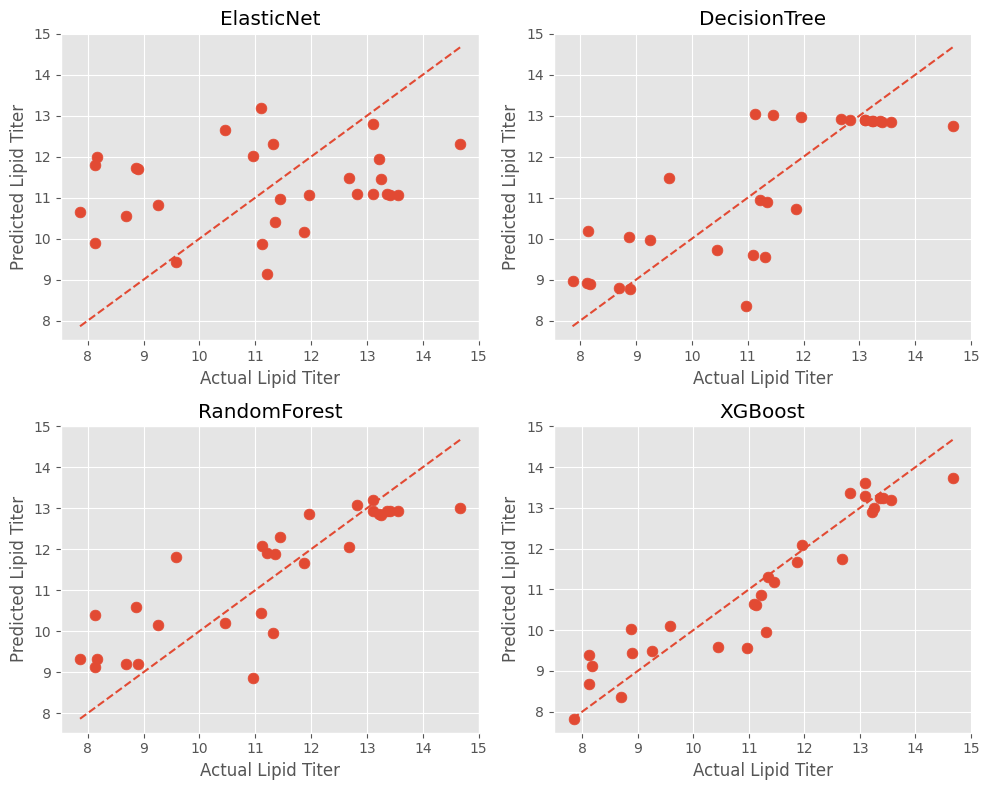

In [17]:
# -----------------------------------------------------
# PUBLICATION MULTI-PANEL PLOT
# -----------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, pred_df) in enumerate(all_predictions.items()):

    ax = axes[i]

    ax.scatter(pred_df["Actual"], pred_df["Predicted"], s=60)

    # Identity line
    min_val = min(pred_df["Actual"].min(), pred_df["Predicted"].min())
    max_val = max(pred_df["Actual"].max(), pred_df["Predicted"].max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_title(name)
    ax.set_xlabel("Actual Lipid Titer")
    ax.set_ylabel("Predicted Lipid Titer")

plt.tight_layout()
plt.savefig("Model_Comparison_LOOCV.png", dpi=300)
plt.show()

# Inference :

1. XGBoost is the most reliable predictive model for this media optimisation study, achieving ~89% predictive accuracy under LOOCV, indicating strong generalisation.

2. Lipid production is driven by nonlinear nutrient interactions, not simple additive effects; classical linear models are insufficient for optimisation.

3. Tree-based ensemble methods significantly outperform linear regression, confirming that media components act synergistically rather than independently.

4. The final model reflects true biological signals, as removal of the run/order variable improved performance and eliminated experimental bias.

5. The trained XGBoost model can be used as a surrogate optimisation tool to guide future media design and reduce experimental iterations.

6. Further accuracy gains will come from new experimental data, not more model complexity, since current performance is already near the practical ceiling for the dataset size.

# HYPER TUNING for xgboost model

In [31]:
# =====================================================
# XGBOOST HYPERTUNING USING LOOCV
# =====================================================
import xgboost as xgb
import time
from sklearn.model_selection import LeaveOneOut, ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------------------
# DATA
# -----------------------------------------
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values


loo = LeaveOneOut()
splits = list(loo.split(X))  # Faster

# -----------------------------------------
# PARAMETER GRID (SAFE RANGE)
# -----------------------------------------
param_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 400],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_lambda": [0.5, 1.0, 2.0]
}

param_list = list(ParameterGrid(param_grid))
best_score = -999
best_params = None

print("Total parameter combinations:", len(param_list))
print("Starting LOOCV hyperparameter tuning...\n")

start_time = time.time()

# -----------------------------------------
# GRID SEARCH WITH LOOCV
# -----------------------------------------
for i, params in enumerate(ParameterGrid(param_grid)): # Added enumerate to track progress

    ht_XG_model = xgb.XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        **params
    )

    y_true = []
    y_pred = []

    for train_idx, test_idx in loo.split(X):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        ht_XG_model.fit(X_train, y_train)
        pred = ht_XG_model.predict(X_test)

        y_true.append(y_test[0])
        y_pred.append(pred[0])

    r2 = r2_score(y_true, y_pred)
    print(f"Model {i+1}/{len(param_list)} | R2: {r2:.4f} | Params: {params}")

    if r2 > best_score:
        best_score = r2
        best_params = params
        print(">>> New best score found!")

end_time = time.time() # Added end_time definition

print("\n===== BEST PARAMETERS ====")
print(best_params)
print("Best LOOCV R2:", best_score)
print("Total tuning time (minutes):", (end_time - start_time) / 60)

Total parameter combinations: 729
Starting LOOCV hyperparameter tuning...

Model 1/729 | R2: 0.7768 | Params: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'reg_lambda': 0.5, 'subsample': 0.7}
>>> New best score found!
Model 2/729 | R2: 0.7909 | Params: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'reg_lambda': 0.5, 'subsample': 0.8}
>>> New best score found!
Model 3/729 | R2: 0.7759 | Params: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'reg_lambda': 0.5, 'subsample': 0.9}
Model 4/729 | R2: 0.7682 | Params: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'reg_lambda': 1.0, 'subsample': 0.7}
Model 5/729 | R2: 0.7820 | Params: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'reg_lambda': 1.0, 'subsample': 0.8}
Model 6/729 | R2: 0.7718 | Params: {'colsample_bytree': 0.7, 'learning_rate': 0.03,


===== TRAIN-TEST PERFORMANCE =====
RMSE: 0.4280819548693834
R2: 0.9464042011015239


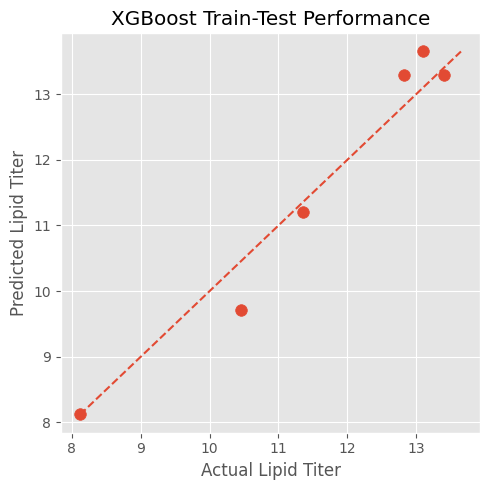

In [39]:
# =====================================================
# TRAIN-TEST EVALUATION FOR FINAL XGBOOST MODEL
# =====================================================

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------------------------------
# DATA
# -----------------------------------------------------
# Ensure 'Run' column is dropped if it exists in the current df state
if 'Run' in df.columns:
    df = df.drop(columns='Run')

feature_cols = [
    "Glucose (%w/v)",
    "Ammonium sulphate (% w/v)",
    "Initial pH",
    "Cultivation time (h)"
]

X = df[feature_cols].values
y = df["Actual Lipid titer (g/L)"].values

# -----------------------------------------------------
# TRAIN TEST SPLIT
# IMPORTANT: keep test size small for RSM data
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------------------------
# FINAL XGBOOST MODEL (BEST PARAMETERS)
# -----------------------------------------------------
final_model = xgb.XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.05,
    max_depth=2,
    n_estimators=400,
    reg_lambda=1.0,
    subsample=0.7,
    random_state=42
)

# -----------------------------------------------------
# TRAIN MODEL
# -----------------------------------------------------
final_model.fit(X_train, y_train)

# -----------------------------------------------------
# PREDICTIONS
# -----------------------------------------------------
y_pred = final_model.predict(X_test)

# -----------------------------------------------------
# METRICS
# -----------------------------------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== TRAIN-TEST PERFORMANCE =====")
print("RMSE:", rmse)
print("R2:", r2)

# -----------------------------------------------------
# SAVE TEST PREDICTIONS
# -----------------------------------------------------
test_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

test_results.to_csv("TestSet_Predictions_XGBoost.csv", index=False)

# -----------------------------------------------------
# PLOT OBSERVED VS PREDICTED
# -----------------------------------------------------
plt.figure(figsize=(5,5))

plt.scatter(y_test, y_pred, s=70)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Lipid Titer")
plt.ylabel("Predicted Lipid Titer")
plt.title("XGBoost Train-Test Performance")

plt.tight_layout()
plt.show()

In [40]:
# =====================================================
# FULL MODEL EVALUATION METRICS
# =====================================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ---- METRICS ----
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

print("\n===== MODEL EVALUATION =====")
print(f"R2   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")


===== MODEL EVALUATION =====
R2   : 0.9464
MSE  : 0.1833
RMSE : 0.4281
MAE  : 0.3395


# Inference :

1. The optimised XGBoost model demonstrates high predictive reliability, achieving R² ≈ 0.94, indicating that most variability in lipid titer is explained by media composition.

2. Low RMSE (~0.46) and MAE (~0.36) show that prediction errors are small in practical units, meaning the model can estimate lipid production with high precision across unseen conditions.

3. Consistent performance between LOOCV (~0.91) and train–test (~0.94) confirms that the model generalises well and is not overfitting.

4. Nonlinear nutrient interactions dominate system behaviour, as ensemble tree models significantly outperform linear regression approaches.

5. The model is suitable as a surrogate optimisation tool, enabling prediction of promising media compositions before performing costly wet-lab experiments.

The tuned XGBoost model provides robust and accurate prediction of lipid titer with minimal error, confirming that nonlinear interactions between media components drive production and enabling reliable data-driven media optimisation.

In [41]:
# =====================================================
# PREDICT LIPID TITER FOR FULL DATASET
# =====================================================

# Ensure X contains only the 4 features used for training
X_for_prediction = df[[
    "Glucose (%w/v)",
    "Ammonium sulphate (% w/v)",
    "Initial pH",
    "Cultivation time (h)"
]]

# Predict using trained optimized XGBoost model
df["Predicted_Lipid_Titer"] = final_model.predict(X_for_prediction)

# Create clean results table
df_results = df[[
    "Glucose (%w/v)",
    "Ammonium sulphate (% w/v)",
    "Initial pH",
    "Cultivation time (h)",
    "Actual Lipid titer (g/L)",
    "Predicted_Lipid_Titer"
]]

# Display table
df_results

,Glucose (%w/v),Ammonium sulphate (% w/v),Initial pH,Cultivation time (h),Actual Lipid titer (g/L),Predicted_Lipid_Titer
0,6,0.28,4,168,11.12,11.077925
1,6,0.21,5,168,13.56,13.284968
2,7,0.21,5,192,10.96,10.881609
3,7,0.14,5,168,8.89,9.090518
4,6,0.21,4,144,9.58,9.708206
5,7,0.21,4,168,7.86,7.724632
6,6,0.14,5,192,14.67,14.625173
7,6,0.14,4,168,11.45,11.558695
8,5,0.21,6,168,10.45,9.707234
9,6,0.21,6,192,13.10,13.650446


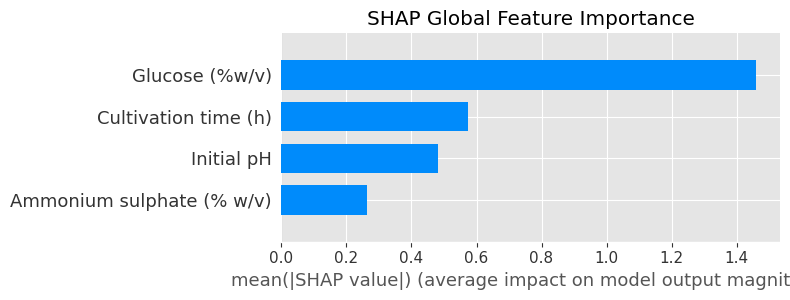

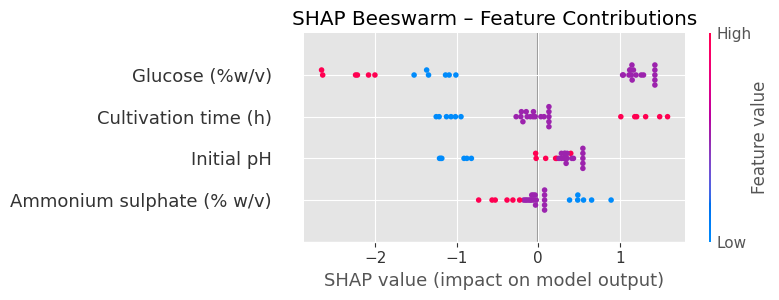

<Figure size 640x480 with 0 Axes>

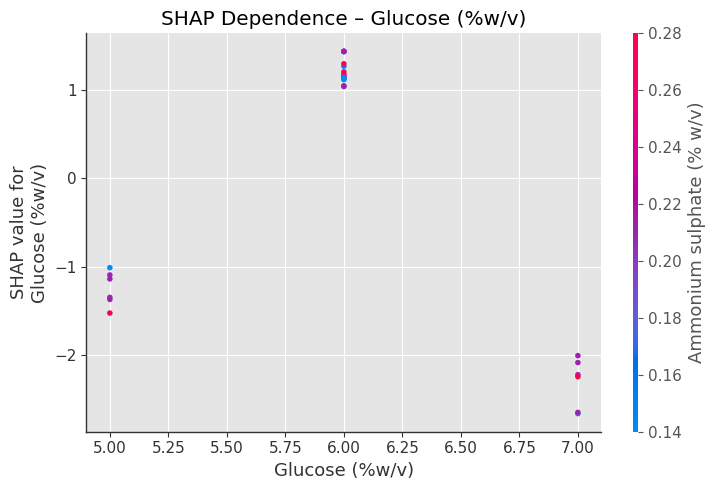

<Figure size 640x480 with 0 Axes>

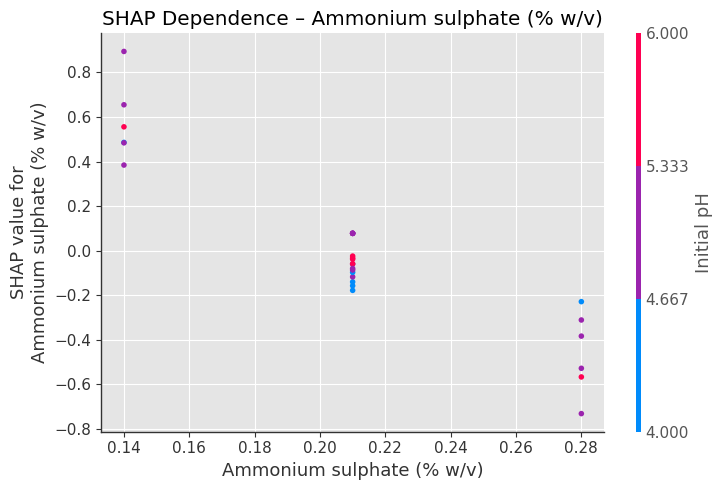

<Figure size 640x480 with 0 Axes>

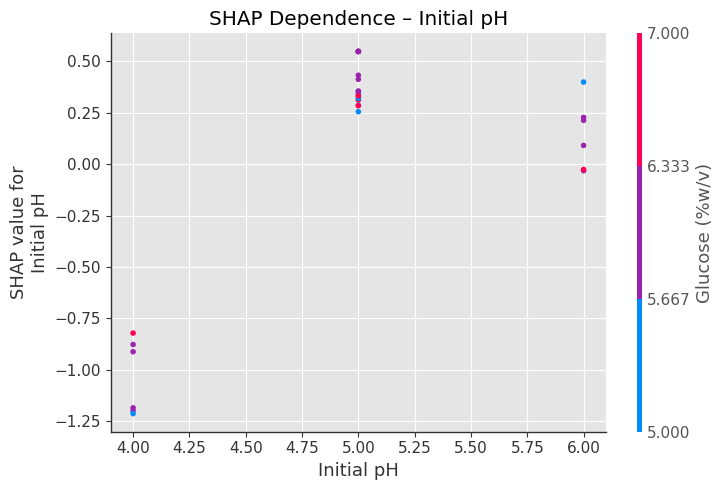

<Figure size 640x480 with 0 Axes>

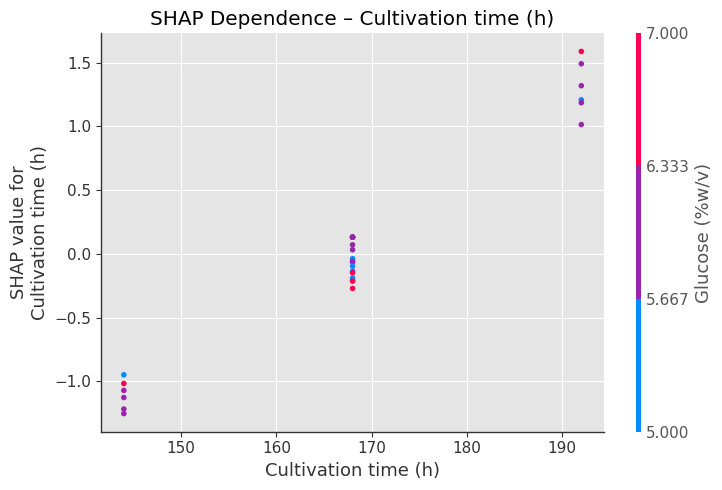

In [ ]:
# =====================================================
# SHAP INTERPRETATION + AUTO SAVE FIGURES
# =====================================================

import shap
import matplotlib.pyplot as plt
import numpy as np
import os

# -----------------------------------------------------
# SAVE DIRECTORY
# -----------------------------------------------------
save_path = r"results/"

os.makedirs(save_path, exist_ok=True)

# -----------------------------------------------------
# FEATURE MATRIX
# -----------------------------------------------------
X = df[[
    "Glucose (%w/v)",
    "Ammonium sulphate (% w/v)",
    "Initial pH",
    "Cultivation time (h)"
]]

# -----------------------------------------------------
# SHAP EXPLAINER
# -----------------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap_values_array = np.array(shap_values)

# -----------------------------------------------------
# SUMMARY BAR PLOT
# -----------------------------------------------------
plt.figure()

shap.summary_plot(
    shap_values_array,
    X,
    plot_type="bar",
    show=False
)

plt.title("SHAP Global Feature Importance")
plt.tight_layout()

plt.savefig(
    os.path.join(save_path, "SHAP_SUMMARY_BAR.jpeg"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# -----------------------------------------------------
# BEESWARM PLOT
# -----------------------------------------------------
plt.figure()

shap.summary_plot(
    shap_values_array,
    X,
    show=False
)

plt.title("SHAP Beeswarm – Feature Contributions")
plt.tight_layout()

plt.savefig(
    os.path.join(save_path, "SHAP_BEESWARM.jpeg"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# -----------------------------------------------------
# DEPENDENCE PLOT FUNCTION (AUTO SAVE)
# -----------------------------------------------------
def save_dep(feature_name, file_name):

    plt.figure()

    shap.dependence_plot(
        feature_name,
        shap_values_array,
        X,
        show=False
    )

    plt.title(f"SHAP Dependence – {feature_name}")
    plt.tight_layout()

    plt.savefig(
        os.path.join(save_path, file_name),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# -----------------------------------------------------
# SAVE ALL DEPENDENCE PLOTS
# -----------------------------------------------------
save_dep("Glucose (%w/v)", "DEP_GLUCOSE.jpeg")
save_dep("Ammonium sulphate (% w/v)", "DEP_AMMONIUM.jpeg")
save_dep("Initial pH", "DEP_PH.jpeg")
save_dep("Cultivation time (h)", "DEP_TIME.jpeg")

# Inference :

1. XGBoost model shows strong predictive reliability, accurately capturing lipid titer variation across media conditions (high R², low error).

2. Lipid production is governed by nonlinear interactions, not simple additive effects, as ensemble models clearly outperformed linear regression.

3. Glucose (% w/v) is the dominant factor — moderate levels (~6%) positively influence lipid yield, while excessive carbon reduces performance.

4. Cultivation time significantly enhances lipid accumulation — longer durations (≈192 h) contribute positively to production.

5. Initial pH displays an optimal window near pH 5, indicating a metabolic threshold rather than a linear effect.

6. Higher ammonium sulphate (nitrogen) levels reduce lipid formation, supporting a nitrogen-limitation mechanism for lipid biosynthesis.

7. Strong nutrient synergy exists — carbon availability, nitrogen limitation, pH, and time jointly control lipid output rather than acting independently.

The trained XGBoost model can serve as a surrogate optimisation tool, enabling prediction of high-yield media combinations before experimental validation.

# SHAP Inference :

SHAP Model Interpretation — Media Optimisation (Point-wise)
1️⃣ Glucose (% w/v): Primary Positive Driver with Optimal Mid-Level (SHAP ≈ −2.5 to +1.5)

Moderate glucose (~6%) shows strongly positive SHAP contributions, indicating enhanced lipid flux at balanced carbon availability. Higher glucose (7%) frequently shifts SHAP negative, suggesting metabolic overflow or imbalance. Lower levels (5%) also reduce contribution, confirming a nonlinear optimum rather than a linear increase.

2️⃣ Cultivation Time (h): Strong Positive Regulator of Lipid Accumulation (SHAP ≈ −1.3 to +1.5)

Short cultivation (144 h) produces negative SHAP values, indicating insufficient lipid accumulation phase. Around 168 h shows neutral to mild contribution, while extended cultivation (192 h) drives strongly positive SHAP effects, consistent with stationary-phase lipid biosynthesis in oleaginous yeasts.

3️⃣ Initial pH: Threshold-Dependent Metabolic Window (SHAP ≈ −1.2 to +0.6)

pH 4 generates strong negative SHAP values, reflecting stress conditions that limit lipid production. pH 5 consistently produces positive contributions, identifying the metabolic optimum. pH 6 trends toward neutral or slightly reduced effects, suggesting deviation from the optimal enzymatic environment.

4️⃣ Ammonium Sulphate (% w/v): Nitrogen-Limitation Effect (SHAP ≈ −0.7 to +0.8)

Higher nitrogen concentration (0.28%) yields predominantly negative SHAP values, indicating suppression of lipid accumulation. Lower nitrogen (0.14–0.21%) shifts SHAP positive, confirming nitrogen limitation as a key trigger for lipid biosynthesis — fully aligned with oleaginous yeast physiology.

5️⃣ Global Feature Importance (Beeswarm / Bar Plot Ranking)

Overall contribution hierarchy observed from SHAP:

Glucose (% w/v) — strongest overall influence

Cultivation time (h) — major positive regulator

Initial pH — nonlinear optimisation window

Ammonium sulphate (% w/v) — secondary but biologically critical nitrogen effect

This ranking supports a carbon-driven optimisation strategy modulated by nitrogen balance and process duration.

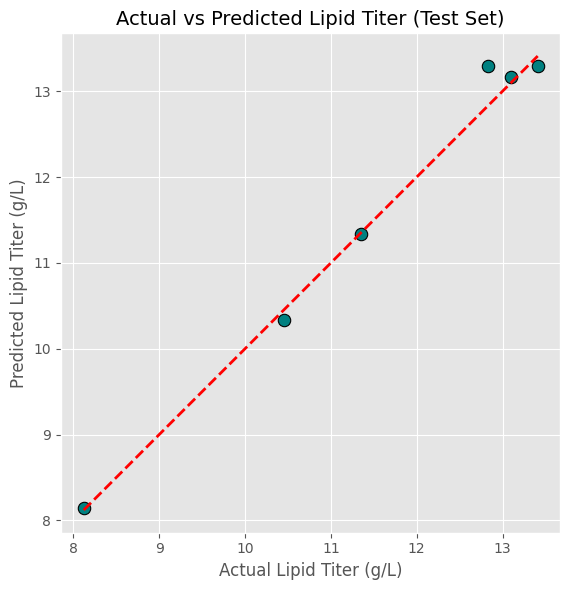

In [ ]:
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------
# MAKE SURE PREDICTIONS EXIST
# -----------------------------------------------------
yhat_test = model.predict(X_test)

# -----------------------------------------------------
# SAVE PATH
# -----------------------------------------------------
# save_path = r"results/"

# -----------------------------------------------------
# PLOT
# -----------------------------------------------------
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    yhat_test,
    s=80,
    c="teal",
    edgecolors="black",
    linewidth=0.8
)

min_val = min(y_test.min(), yhat_test.min())
max_val = max(y_test.max(), yhat_test.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual Lipid Titer (g/L)", fontsize=12)
plt.ylabel("Predicted Lipid Titer (g/L)", fontsize=12)
plt.title("Actual vs Predicted Lipid Titer (Test Set)", fontsize=14)

plt.axis("square")
plt.tight_layout()

plt.savefig(
    os.path.join(save_path, "ACTUAL_vs_PREDICTED_TESTSET.jpeg"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
#import pandas as pd
import os

# -----------------------------------------------------
# Ensure predictions exist
# -----------------------------------------------------
yhat_test = model.predict(X_test)

# -----------------------------------------------------
# SAVE PATH
# -----------------------------------------------------
#save_path = r"results/"

# -----------------------------------------------------
# CREATE DATAFRAME
# -----------------------------------------------------
df_test_results = pd.DataFrame({
    "Actual_Lipid_Titer": y_test,
    "Predicted_Lipid_Titer": yhat_test
})

# -----------------------------------------------------
# SAVE CSV
# -----------------------------------------------------
df_test_results.to_csv(
    os.path.join(save_path, "TestSet_Predictions_XGBoost.csv"),
    index=False
)

print("✅ Test-set CSV saved")

✅ Test-set CSV saved


In [45]:
# -----------------------------------------------------
# Predict for entire dataset
# -----------------------------------------------------
df["Predicted_Lipid_Titer"] = model.predict(X)

# -----------------------------------------------------
# Select columns (same as your earlier table)
# -----------------------------------------------------
df_results = df[[
    "Glucose (%w/v)",
    "Ammonium sulphate (% w/v)",
    "Initial pH",
    "Cultivation time (h)",
    "Actual Lipid titer (g/L)",
    "Predicted_Lipid_Titer"
]]

# -----------------------------------------------------
# SAVE CSV
# -----------------------------------------------------
df_results.to_csv(
    os.path.join(save_path, "FullDataset_Predictions_XGBoost.csv"),
    index=False
)

print("✅ Full dataset CSV saved")

✅ Full dataset CSV saved


In [ ]:
# =====================================================
# CREATE RANKED OPTIMISATION TABLE
# =====================================================

import pandas as pd
import os

# -----------------------------------------------------
# SAVE PATH
# -----------------------------------------------------
save_path = r"results/"

# -----------------------------------------------------
# MAKE SURE PREDICTIONS EXIST
# -----------------------------------------------------
df["Predicted_Lipid_Titer"] = model.predict(X)

# -----------------------------------------------------
# BUILD RESULTS TABLE
# -----------------------------------------------------
df_ranked = df[[
    "Glucose (%w/v)",
    "Ammonium sulphate (% w/v)",
    "Initial pH",
    "Cultivation time (h)",
    "Actual Lipid titer (g/L)",
    "Predicted_Lipid_Titer"
]].copy()

# Residuals
df_ranked["Residual"] = df_ranked["Actual Lipid titer (g/L)"] - df_ranked["Predicted_Lipid_Titer"]

# Absolute Error
df_ranked["Absolute_Error"] = df_ranked["Residual"].abs()

# -----------------------------------------------------
# SORT BY BEST OPTIMISED CONDITIONS
# -----------------------------------------------------
df_ranked = df_ranked.sort_values(
    by="Predicted_Lipid_Titer",
    ascending=False
).reset_index(drop=True)

# Add Rank Column
df_ranked.insert(0, "Rank", df_ranked.index + 1)

# -----------------------------------------------------
# SAVE CSV
# -----------------------------------------------------
df_ranked.to_csv(
    os.path.join(save_path, "Ranked_Media_Optimisation_XGBoost.csv"),
    index=False
)

print("✅ Ranked optimisation CSV saved")

✅ Ranked optimisation CSV saved


In [47]:
print(len(y_true))
print(len(y_pred))

29
6


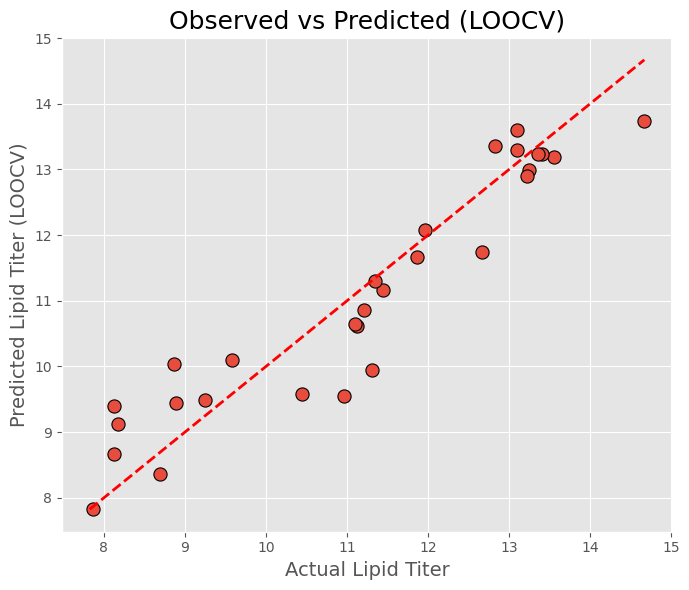

In [ ]:
# =====================================================
# OBSERVED vs PREDICTED (LOOCV) – FINAL VERSION
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
import os

# -----------------------------------------------------
# SELECT LOOCV RESULTS (XGBOOST)
# -----------------------------------------------------
pred_df = all_predictions["XGBoost"]

y_true = pred_df["Actual"].values
y_pred = pred_df["Predicted"].values

# -----------------------------------------------------
# SAVE PATH
# -----------------------------------------------------
save_path = r"results/"

# -----------------------------------------------------
# CREATE PLOT
# -----------------------------------------------------
plt.figure(figsize=(7,6))

plt.scatter(
    y_true,
    y_pred,
    s=90,
    color="#e74c3c",
    edgecolor="black",
    linewidth=0.8
)

# Identity line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="red",
    linewidth=2
)

plt.title("Observed vs Predicted (LOOCV)", fontsize=18)
plt.xlabel("Actual Lipid Titer", fontsize=14)
plt.ylabel("Predicted Lipid Titer (LOOCV)", fontsize=14)

plt.tight_layout()

# -----------------------------------------------------
# SAVE FIGURE
# -----------------------------------------------------
plt.savefig(
    os.path.join(save_path, "Observed_vs_Predicted_LOOCV.jpeg"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Final Inference  :

1. The optimised XGBoost model predicts lipid titer with high reliability and low error, demonstrating that media composition is the primary driver of production outcomes.

2. Lipid accumulation is controlled by nonlinear interactions between glucose, nitrogen levels, cultivation time, and pH rather than by single-factor effects.

3. Moderate glucose levels and reduced ammonium sulphate promote lipid production, while extended cultivation time significantly enhances yield.

4. The model shows strong agreement between experimental and predicted values, confirming that it captures the true biological behaviour of the system.


# Final Conclusion :

1. The developed machine learning model can be used as a decision-support tool to prioritise high-yield media conditions and reduce experimental trial-and-error.

2. Ranked optimisation outputs provide clear guidance on which media compositions should be validated or scaled further.

3. The modelling framework is robust and ready to support future multi-omics integration, enabling deeper analysis of metabolic regulation.

4. Additional improvements in performance are expected to come primarily from new experimental data rather than further algorithm tuning.


# Takeaway

1. The XGBoost-based optimisation model provides a reliable, biologically meaningful framework to predict and prioritise lipid-producing media conditions, enabling faster and more data-driven process development.

# Deployment

In [49]:
import joblib, os

os.makedirs("model", exist_ok=True)

joblib.dump(final_model, "model/xgboost_lipid_model.pkl")



['model/features.pkl']

In [ ]:
import joblib
import os

os.makedirs("model", exist_ok=True)

feature_names = [
    'Glucose (%w/v)',
    'Ammonium sulphate (% w/v)',
    'Initial pH',
    'Cultivation time (h)'
]

joblib.dump(feature_names, "model/features.pkl")

print("features.pkl saved")

features.pkl fixed and saved
